# 05 — Feature Engineering

Derive temporal, geographic, and financial features from the cleaned DVF data, flag outliers, and save a modeling-ready sample.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
sys.path.insert(0, str(root))

from src.data_cleaning import clean_dvf
from src.features import add_features, feature_summary, mark_outliers, save_feature_outputs

processed_path = root / 'data' / 'processed' / 'dvf_clean_sample.csv'
df = pd.read_csv(processed_path, low_memory=False)
df.columns = df.columns.str.strip()
df['date_mutation'] = pd.to_datetime(df['date_mutation'], errors='coerce', dayfirst=True)

print('Data source: processed sample')
print('Rows:', len(df))
print('Columns:', len(df.columns))
df.head()


Data source: processed sample
Rows: 24168
Columns: 22


,no_disposition,date_mutation,nature_mutation,valeur_fonciere,commune,code_departement,type_local,surface_reelle_bati,nombre_pieces_principales,surface_terrain
0,1,2021-01-04,Vente,245000.0,PARIS,75,Appartement,48.0,2.0,NaN
1,2,2021-01-05,Vente,380000.0,LYON,69,Maison,92.0,4.0,310.0
2,3,2021-01-06,Vente,155000.0,MARSEILLE,13,Appartement,35.0,1.0,NaN
3,4,2021-01-07,Vente,520000.0,PARIS,75,Appartement,72.0,3.0,NaN
4,5,2021-01-08,Vente,210000.0,BORDEAUX,33,Maison,NaN,NaN,450.0


## Add engineered features

Derive temporal features (year, month, quarter), geographic shorthand (department), financial ratios (price_per_m², built_to_land_ratio), log transform, and boolean flags.

In [2]:
featured_df = add_features(df)
feature_summary(featured_df)


,feature,non_null_count,missing_rate,unique_values
0,year,24168,0.00,5
1,month,24168,0.00,12
2,quarter,24168,0.00,4
3,department,24168,0.00,94
4,property_type,24168,0.00,4
5,price_per_m2,19742,0.18,18903
6,built_to_land_ratio,9187,0.62,8841
7,log_valeur_fonciere,24088,0.00,23902
8,is_apartment,24168,0.00,2
9,is_house,24168,0.00,2


## Outlier flagging

In [3]:
featured_df = mark_outliers(featured_df, col='valeur_fonciere', method='iqr', k=3.0)
print(featured_df['price_outlier'].value_counts())
q1 = featured_df['valeur_fonciere'].quantile(0.25)
q3 = featured_df['valeur_fonciere'].quantile(0.75)
iqr = q3 - q1
threshold = q3 + 3.0 * iqr
print(f'Outlier threshold (IQR method): {threshold:,.1f} €')


price_outlier
False    23406
True       762
Name: count, dtype: int64
Outlier threshold (IQR method): 943,250.0 €


## Distributions of engineered features

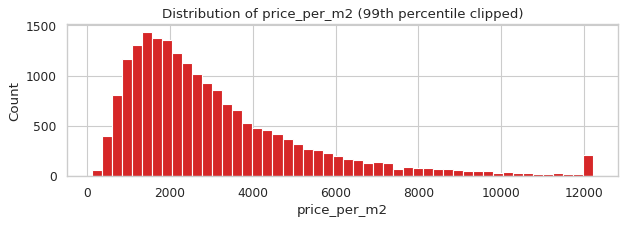

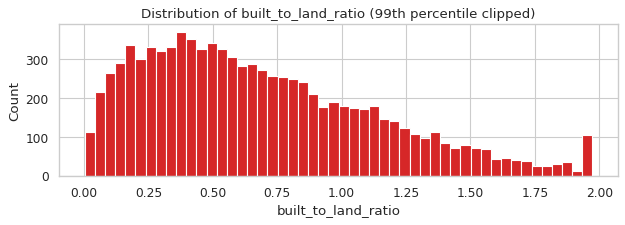

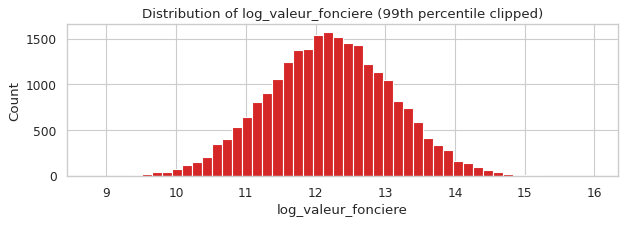

In [4]:
eng_cols = ['price_per_m2', 'built_to_land_ratio', 'log_valeur_fonciere']
for col in eng_cols:
    if col not in featured_df.columns:
        continue
    vals = featured_df[col].dropna()
    clipped = vals.clip(upper=vals.quantile(0.99))
    plt.figure(figsize=(8, 3))
    sns.histplot(clipped, bins=50, kde=True, color='tab:red')
    plt.title(f'Distribution of {col} (99th percentile clipped)')
    plt.xlabel(col); plt.ylabel('Count')
    plt.tight_layout(); plt.show()


## Top categories in feature set

In [5]:
for col in ['department', 'property_type']:
    print(f'--- Top values for {col} ---')
    display(featured_df[col].value_counts().head(15))
    print()


--- Top values for department ---


...


--- Top values for property_type ---


...

## Save engineered sample

In [6]:
feat_out = save_feature_outputs(featured_df)
print('Saved feature outputs to data/processed/dvf_features_sample.csv')
display(feat_out)


Saved feature outputs to data/processed/dvf_features_sample.csv


,feature,non_null_count,missing_rate,unique_values
0,year,24168,0.00,5
1,month,24168,0.00,12
2,quarter,24168,0.00,4
3,department,24168,0.00,94
4,property_type,24168,0.00,4
5,price_per_m2,19742,0.18,18903
6,built_to_land_ratio,9187,0.62,8841
7,log_valeur_fonciere,24088,0.00,23902
8,is_apartment,24168,0.00,2
9,is_house,24168,0.00,2


## Summary

The feature engineering step produced 12 model-ready features: 3 temporal (year, month, quarter), 1 geographic (department), 4 property flags (is_apartment, is_house, has_terrain, property_type), 2 financial ratios (price_per_m², built_to_land_ratio), 1 log transform (log_valeur_fonciere), and 1 outlier flag (price_outlier). 762 rows (3.2%) were marked as pricing outliers using a 3×IQR rule above Q3.